# Pipeline Sandbox - Tech Challenge Fase 4

Notebook didático para demonstrar o fluxo do projeto e testar dois alvos de treinamento para a LSTM:

- `log_returns`: treina com log-retornos e reconstrói o preço previsto;
- `raw_close`: treina diretamente com o preço bruto de fechamento escalonado.

A API e o `src/train.py` continuam usando o fluxo oficial por log-retornos. A flag abaixo serve para experimentação no notebook.

## 1. Imports, configuração e flag de experimento

Altere `TRAIN_TARGET_MODE` para comparar os dois modos.

In [1]:
import os
import sys
import copy
from pathlib import Path
from dotenv import load_dotenv

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader, TensorDataset
import mlflow

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Carrega configurações do .env
load_dotenv(PROJECT_ROOT / ".env")

from src.data_loader import load_yfinance, load_csv, build_close_frame, build_return_frame
from src.model import StockLSTM
from src.train import TrainConfig, run_training_pipeline

# Resolução limpa de caminhos para o modelo e MLflow
model_dir = os.getenv("MODEL_DIR", "models/lstm_petr4")
MODEL_PATH = Path(model_dir) if Path(model_dir).is_absolute() else PROJECT_ROOT / model_dir

mlflow_uri = os.getenv("MLFLOW_TRACKING_URI", "mlruns")
MLFLOW_URI = mlflow_uri if mlflow_uri.startswith(("file://", "http://", "https://")) else (PROJECT_ROOT / mlflow_uri).as_uri()

# Configurações de treino
TRAIN_TARGET_MODE = "log_returns"
DEVICE_MODE = "cpu"

# Configuração do MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("stock_lstm_notebook_experiments")
print("Experimento MLflow: stock_lstm_notebook_experiments")

# Seleção de dispositivo
mode = DEVICE_MODE.lower()
if mode == "cpu":
    device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("PyTorch:", torch.__version__, "| CUDA:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
elif mode == "cuda":
    raise RuntimeError("CUDA solicitado, mas não está disponível neste ambiente.")
else:
    device = torch.device("cpu")
    print("CUDA indisponível neste kernel. Usando CPU.")

print("Modo de treino:", TRAIN_TARGET_MODE)
print("Device selecionado:", device)

cfg = TrainConfig(
    symbol="PETR4.SA",
    start_date="2018-01-01",
    output_dir=str(MODEL_PATH),
    window_size=60,
    max_epochs=100,
    patience=10,
    batch_size=32,
    learning_rate=1e-3,
    dropout=0.20,
)
cfg

Experimento MLflow: stock_lstm_notebook_experiments
Modo de treino: log_returns
Device selecionado: cpu


f:\dev\fiap_tech_cha_fase4\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


TrainConfig(symbol='PETR4.SA', start_date='2018-01-01', end_date=None, window_size=60, train_ratio=0.7, val_ratio=0.15, hidden_size=64, num_layers=1, dropout=0.2, learning_rate=0.001, weight_decay=0.0001, batch_size=32, max_epochs=100, patience=10, output_dir='f:\\dev\\fiap_tech_cha_fase4\\models\\lstm_petr4', seed=42)

## 2. Coleta dos dados

Baixamos dados pelo Yahoo Finance. Para CSV local, use `load_csv()`.

In [2]:
csv_path = os.getenv("DATA_CSV_PATH")
if csv_path:
    csv_path = Path(csv_path) if Path(csv_path).is_absolute() else PROJECT_ROOT / csv_path
    df_raw = load_csv(csv_path)
else:
    df_raw = load_yfinance(cfg.symbol, cfg.start_date, cfg.end_date)
print(df_raw.shape)
df_raw.tail()

(2080, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-05-12,45.680000,45.680000,46.250000,45.400002,46.250000,81072700
2026-05-13,44.570000,44.570000,45.830002,44.360001,45.770000,57251900
2026-05-14,45.000000,45.000000,45.369999,44.380001,44.459999,47760000
2026-05-15,45.470001,45.470001,45.540001,44.980000,45.389999,59380500
2026-05-18,46.439999,46.439999,46.459999,44.470001,45.099998,57307600


## 3. Fechamentos e log-retornos

O modo `raw_close` usa `close_frame`. O modo `log_returns` usa `return_frame`.

In [3]:
close_frame = build_close_frame(df_raw)
return_frame = build_return_frame(df_raw)

print("Fechamentos:", close_frame.shape)
print("Log-retornos:", return_frame.shape)
display(close_frame.tail())
display(return_frame.tail())

Fechamentos: (2080, 1)
Log-retornos: (2079, 2)


,Close
Date,
2026-05-12,45.680000
2026-05-13,44.570000
2026-05-14,45.000000
2026-05-15,45.470001
2026-05-18,46.439999


,Close,Log_Return
Date,,
2026-05-12,45.680000,-0.016285
2026-05-13,44.570000,-0.024600
2026-05-14,45.000000,0.009602
2026-05-15,45.470001,0.010390
2026-05-18,46.439999,0.021108


## 4. Funções locais do notebook para comparar os modos

Estas funções existem só no notebook. Elas permitem trocar o alvo sem alterar o pipeline oficial (`src/train.py`).

In [4]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loader(X, y, batch_size: int, shuffle: bool):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape_pct": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def directional_accuracy(y_true, y_pred, last_close):
    return float(np.mean((np.asarray(y_true) > np.asarray(last_close)) == (np.asarray(y_pred) > np.asarray(last_close))) * 100)


def create_experiment_windows(close_frame, return_frame, cfg, mode):
    if mode not in {"log_returns", "raw_close"}:
        raise ValueError("TRAIN_TARGET_MODE deve ser 'log_returns' ou 'raw_close'.")

    if mode == "log_returns":
        frame = return_frame.copy()
        values = frame["Log_Return"].values.astype(np.float32).reshape(-1, 1)
        closes = frame["Close"].values.astype(np.float32)
        dates = frame.index.to_numpy()
    else:
        frame = close_frame.copy()
        values = frame["Close"].values.astype(np.float32).reshape(-1, 1)
        closes = frame["Close"].values.astype(np.float32)
        dates = frame.index.to_numpy()

    n_rows = len(frame)
    train_end_row = int(n_rows * cfg.train_ratio)
    val_end_row = int(n_rows * (cfg.train_ratio + cfg.val_ratio))

    scaler = StandardScaler()
    scaler.fit(values[:train_end_row])
    scaled_values = scaler.transform(values).astype(np.float32)

    X, y, last_closes, target_closes, target_dates, target_rows = [], [], [], [], [], []
    for i in range(cfg.window_size, n_rows):
        X.append(scaled_values[i - cfg.window_size:i])
        y.append(scaled_values[i, 0])
        last_closes.append(closes[i - 1])
        target_closes.append(closes[i])
        target_dates.append(dates[i])
        target_rows.append(i)

    arrays = {
        "X": np.asarray(X, dtype=np.float32),
        "y": np.asarray(y, dtype=np.float32).reshape(-1, 1),
        "last_close": np.asarray(last_closes, dtype=np.float32),
        "target_close": np.asarray(target_closes, dtype=np.float32),
        "target_date": np.asarray(target_dates),
        "target_row": np.asarray(target_rows),
        "scaler": scaler,
        "train_end_row": train_end_row,
        "val_end_row": val_end_row,
        "mode": mode,
    }
    return arrays


def inverse_predictions_to_close(pred_scaled, y_scaled, last_close, scaler, mode):
    pred_value = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    true_value = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if mode == "log_returns":
        y_pred_close = last_close * np.exp(pred_value)
        y_true_close = last_close * np.exp(true_value)
    else:
        y_pred_close = pred_value
        y_true_close = true_value

    return y_true_close, y_pred_close

## 5. Criação das janelas conforme a flag

As duas opções usam a mesma LSTM, mas mudam a escala/semântica do alvo.

In [5]:
exp_data = create_experiment_windows(close_frame, return_frame, cfg, TRAIN_TARGET_MODE)
rows_all = exp_data["target_row"]
train_end_row = exp_data["train_end_row"]
val_end_row = exp_data["val_end_row"]

train_mask = rows_all < train_end_row
val_mask = (rows_all >= train_end_row) & (rows_all < val_end_row)
test_mask = rows_all >= val_end_row

X_train, y_train = exp_data["X"][train_mask], exp_data["y"][train_mask]
X_val, y_val = exp_data["X"][val_mask], exp_data["y"][val_mask]
X_test, y_test = exp_data["X"][test_mask], exp_data["y"][test_mask]
last_close_test = exp_data["last_close"][test_mask]
target_close_test = exp_data["target_close"][test_mask]
dates_test = exp_data["target_date"][test_mask]

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1395, 60, 1) (1395, 1)
Validação: (312, 60, 1) (312, 1)
Teste: (312, 60, 1) (312, 1)


## 6. Modelo LSTM

A entrada tem uma única feature por passo temporal: log-retorno escalonado ou fechamento escalonado, conforme a flag.

In [6]:
model = StockLSTM(
    input_size=X_train.shape[2],
    hidden_size=cfg.hidden_size,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
).to(device)

model

StockLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## 7. Treinamento experimental do notebook

Este treino respeita a flag `TRAIN_TARGET_MODE`. Use esta célula para comparar rapidamente os dois modos.

In [7]:
set_seed(cfg.seed)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
train_loader = make_loader(X_train, y_train, cfg.batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, cfg.batch_size, shuffle=False)

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
patience_count = 0
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, cfg.max_epochs + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            val_losses.append(criterion(model(xb.to(device)), yb.to(device)).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train={train_loss:.8f} | val={val_loss:.8f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= cfg.patience:
            print(f"Early stopping na época {epoch}.")
            break

model.load_state_dict(best_state)
print("Melhor val_loss:", best_val_loss)

Epoch 001 | train=1.01628907 | val=0.27109035
Epoch 010 | train=0.98487252 | val=0.27545456
Early stopping na época 11.
Melhor val_loss: 0.27109035216271876


## 8. Avaliação no teste

As métricas são sempre calculadas em preço final, mesmo quando o alvo treinado é log-retorno.

,mae,rmse,mape_pct
modelo,,,
LSTM,0.4358,0.6145,1.2069
Baseline,0.4370,0.6152,1.2100


Modo de treino: log_returns
Acurácia direcional: 56.09%


,real,lstm,baseline
292,46.220001,48.588902,48.580002
293,47.020000,46.226299,46.220001
294,47.669998,47.025398,47.020000
295,47.770000,47.680302,47.669998
296,47.160000,47.782799,47.770000
297,47.369999,47.171600,47.160000
298,47.520000,47.381199,47.369999
299,48.959999,47.532101,47.520000
300,49.080002,48.976002,48.959999
301,49.340000,49.097401,49.080002


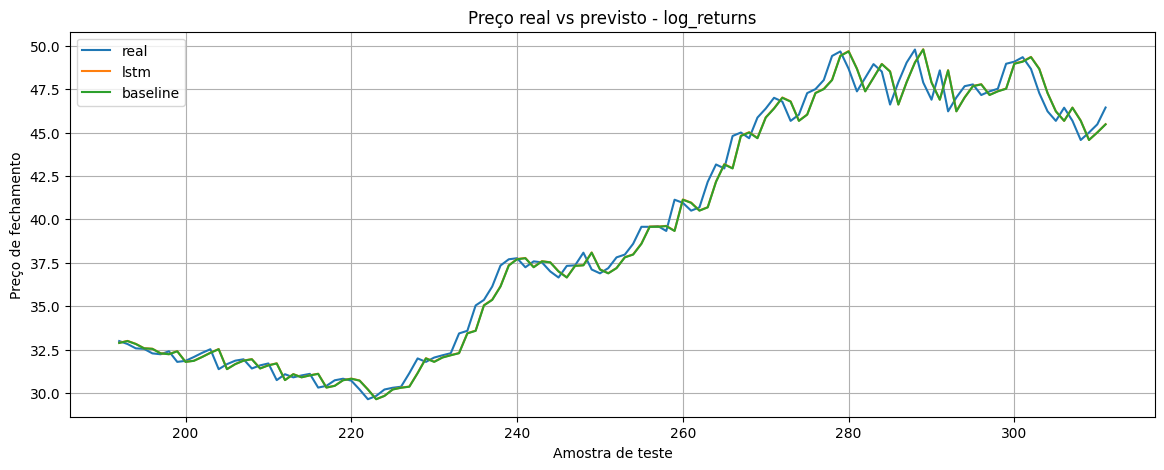

[['mode', 'log_returns', ''],
 ['mae', 0.4358066534384703, 0.43698721054272777],
 ['rmse', 0.6144628817599627, 0.6151771011920872],
 ['mape_pct', 1.2069175397270708, 1.2099818234506354],
 ['directional_acc_pct', 56.08974358974359, '']]

In [8]:
%matplotlib inline

model.eval()

test_loader = DataLoader(
    torch.tensor(X_test, dtype=torch.float32),
    batch_size=256,
    shuffle=False,
)

preds = []

with torch.inference_mode():
    for xb in test_loader:
        xb = xb.to(device)
        y_pred = model(xb)
        preds.append(y_pred.cpu().numpy())

pred_scaled = np.vstack(preds).reshape(-1)

y_true_close, y_pred_close = inverse_predictions_to_close(
    pred_scaled=pred_scaled,
    y_scaled=y_test.reshape(-1),
    last_close=last_close_test,
    scaler=exp_data["scaler"],
    mode=TRAIN_TARGET_MODE,
)

baseline_close = last_close_test

lstm_metrics = regression_metrics(y_true_close, y_pred_close)
baseline_metrics = regression_metrics(y_true_close, baseline_close)
directional_acc = directional_accuracy(
    y_true_close,
    y_pred_close,
    baseline_close,
)

with mlflow.start_run(run_name=f"notebook_{TRAIN_TARGET_MODE}", nested=True):
    mlflow.log_params({
        "symbol": cfg.symbol,
        "target_mode": TRAIN_TARGET_MODE,
        "window_size": cfg.window_size,
        "hidden_size": cfg.hidden_size,
        "num_layers": cfg.num_layers,
        "dropout": cfg.dropout,
        "learning_rate": cfg.learning_rate,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "device": str(device),
    })
    mlflow.log_metrics({
        "lstm_mae": lstm_metrics["mae"],
        "lstm_rmse": lstm_metrics["rmse"],
        "lstm_mape_pct": lstm_metrics["mape_pct"],
        "baseline_mae": baseline_metrics["mae"],
        "baseline_rmse": baseline_metrics["rmse"],
        "baseline_mape_pct": baseline_metrics["mape_pct"],
        "directional_accuracy_pct": directional_acc,
    })

metrics_df = pd.DataFrame(
    [
        {"modelo": "LSTM", **lstm_metrics},
        {"modelo": "Baseline", **baseline_metrics},
    ]
).set_index("modelo")

display(metrics_df.round(4))

print(f"Modo de treino: {TRAIN_TARGET_MODE}")
print(f"Acurácia direcional: {directional_acc:.2f}%")

results_df = pd.DataFrame({
    "real": y_true_close,
    "lstm": y_pred_close,
    "baseline": baseline_close,
})

display(results_df.tail(20).round(4))

ax = results_df.tail(120).plot(
    figsize=(14, 5),
    title=f"Preço real vs previsto - {TRAIN_TARGET_MODE}",
)

ax.set_xlabel("Amostra de teste")
ax.set_ylabel("Preço de fechamento")
ax.grid(True)
plt.show()

metrics = [
    ["mode", TRAIN_TARGET_MODE, ""],
    ["mae", lstm_metrics["mae"], baseline_metrics["mae"]],
    ["rmse", lstm_metrics["rmse"], baseline_metrics["rmse"]],
    ["mape_pct", lstm_metrics["mape_pct"], baseline_metrics["mape_pct"]],
    ["directional_acc_pct", directional_acc, ""],
]

metrics

## 9. Predições de teste

Tabela curta para inspecionar previsões contra valores reais.

In [9]:
predictions = pd.DataFrame({
    "target_date": pd.to_datetime(dates_test),
    "last_close": baseline_close,
    "actual_close": y_true_close,
    "predicted_close_lstm": y_pred_close,
    "absolute_error_lstm": np.abs(y_true_close - y_pred_close),
    "absolute_error_baseline": np.abs(y_true_close - baseline_close),
})

predictions.tail(10)

,target_date,last_close,actual_close,predicted_close_lstm,absolute_error_lstm,absolute_error_baseline
302,2026-05-05,49.340000,48.660000,49.356892,0.696892,0.680000
303,2026-05-06,48.660000,47.270004,48.673771,1.403767,1.389996
304,2026-05-07,47.270000,46.220001,47.277992,1.057991,1.049999
305,2026-05-08,46.220001,45.669998,46.223289,0.553291,0.550003
306,2026-05-11,45.669998,46.430000,45.672123,0.757877,0.760002
307,2026-05-12,46.430000,45.680000,46.436043,0.756042,0.750000
308,2026-05-13,45.680000,44.570004,45.688114,1.118111,1.109997
309,2026-05-14,44.570000,45.000000,44.575691,0.424309,0.430000
310,2026-05-15,45.000000,45.469997,45.006454,0.463543,0.469997
311,2026-05-18,45.470001,46.440002,45.480343,0.959660,0.970001


## 10. Treinamento oficial por log-retornos com MLflow

Quando quiser gerar os artefatos usados pela API, rode o pipeline oficial. Ele também registra parâmetros, perdas, métricas e artefatos no MLflow. Ele sempre usa log-retornos, independentemente da flag experimental acima.

In [10]:
# Descomente para gerar model.pt, preprocessor.joblib e métricas usados pela API.
# results = run_training_pipeline(cfg)
# results["metrics"]

## 11. Payload para a API

A API recebe apenas uma lista cronológica de fechamentos. Com `window_size=60`, envie pelo menos 61 fechamentos.

In [11]:
recent_closes = close_frame["Close"].tail(cfg.window_size + 1).astype(float).tolist()
payload = {
    "symbol": cfg.symbol,
    "closes": recent_closes,
}

payload["closes"][:3], payload["closes"][-3:], len(payload["closes"])

([37.189998626708984, 37.810001373291016, 37.970001220703125],
 [45.0, 45.470001220703125, 46.439998626708984],
 61)

## 12. Próximos passos da demonstração

Com os artefatos salvos pelo treino oficial, suba a API no PowerShell com:

```powershell
$env:PYTHONPATH="src"; uvicorn api:app --reload
```

Depois acesse:

- `http://localhost:8000/` para abrir direto o dashboard;
- `http://localhost:8000/docs` para Swagger;
- `http://localhost:8000/model-card` para resumo do modelo;
- `http://localhost:8000/metrics` para Prometheus.